# Feature check ex5 - correlazione univariata

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

df = pd.read_csv("../data/features_ex5.csv")
y = df["cTS"]
X = df.drop(columns=["cTS"]).select_dtypes(include=[np.number])
print(f"Loaded {X.shape[0]} samples, {X.shape[1]} features")

Loaded 75 samples, 37 features


Prima di incolpare il modello: ogni singola feature correla con cTS da sola? Nessun modello, nessuna CV, solo Spearman per feature.

In [2]:
rows = []
for col in X.columns:
    mask = X[col].notna()
    rho, pval = spearmanr(X.loc[mask, col], y.loc[mask])
    rows.append({"feature": col, "n": int(mask.sum()), "rho": rho, "p": pval})

corr = pd.DataFrame(rows).sort_values("rho", key=lambda s: s.abs(), ascending=False)
print(corr.to_string(index=False, formatters={"rho": "{:.3f}".format, "p": "{:.3f}".format}))

n_sig = (corr["p"] < 0.05).sum()
print(f"\nFeature con p < 0.05 (non corretto per test multipli): {n_sig} su {len(corr)}")
print(f"Attesi per puro caso su {len(corr)} test a soglia 0.05: circa {0.05 * len(corr):.1f}")

                feature  n    rho     p
                sym_hip 75  0.291 0.011
          hip_right_max 75  0.174 0.136
           hip_left_std 75 -0.142 0.224
          knee_left_std 75 -0.131 0.264
          hip_left_mean 75  0.130 0.267
           hip_left_max 75  0.127 0.278
          knee_left_max 75 -0.119 0.310
          hip_right_std 75 -0.097 0.410
           hip_left_min 75  0.089 0.448
         hip_right_mean 75  0.088 0.451
 knee_right_vel_max_abs 75 -0.088 0.452
          hip_right_min 75  0.083 0.477
  knee_left_vel_max_abs 75 -0.079 0.501
knee_right_vel_mean_abs 75 -0.076 0.514
       hip_left_vel_std 75  0.072 0.542
           rep_dur_mean 74  0.065 0.583
         knee_right_std 75 -0.062 0.594
     knee_right_vel_std 75 -0.059 0.612
           hip_left_rom 75 -0.057 0.627
 knee_left_vel_mean_abs 75 -0.048 0.683
   hip_left_vel_max_abs 75  0.048 0.685
        knee_right_mean 75  0.043 0.713
         knee_left_mean 75  0.040 0.731
         knee_right_max 75  0.037 0.751


## Grafico: rho di ogni feature, ordinate per forza

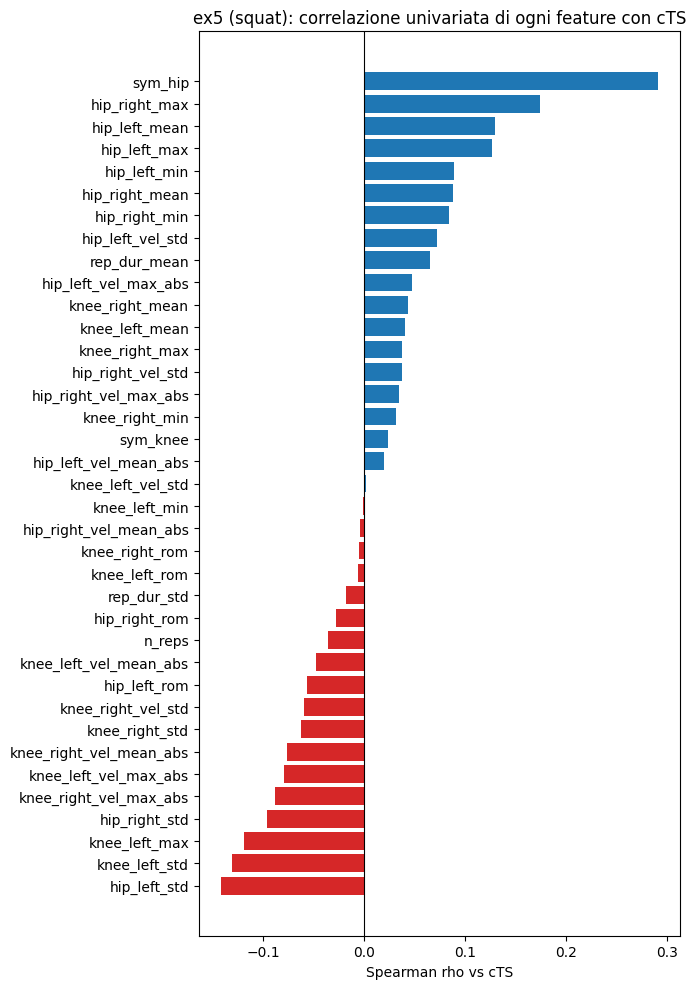

In [3]:
plot_df = corr.sort_values("rho")
colors = ["tab:red" if r < 0 else "tab:blue" for r in plot_df["rho"]]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(plot_df["feature"], plot_df["rho"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman rho vs cTS")
ax.set_title("ex5 (squat): correlazione univariata di ogni feature con cTS")
plt.tight_layout()
plt.show()

## Conclusioni

- Solo 1 feature su 37 ha p < 0.05 (`sym_hip`), e con 37 test indipendenti ci si aspettano circa 1.9 falsi positivi per puro caso a questa soglia: non e un segnale robusto.
- Nessuna feature cinematica del solo squat (ex5) correla in modo affidabile con cTS.
- Il problema non e il modello (Ridge/RF nella CV precedente): il segnale manca gia a livello di singola feature.
- cTS e un punteggio di gravita clinica generale del paziente, identico su tutti e 5 gli esercizi: chiedere di prevederlo da un solo esercizio isolato e un compito diverso da valutare la qualita di quella singola esecuzione.